# Figure 4 - Breakpoint analysis
Mathieu Bourdenx - UCL - 2026

In [3]:
import os
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from joblib import Parallel, delayed

import pickle

# Import custom functions
from src.breakpoint_analysis import bkpoint_analysis

# Housekeeping

In [11]:
raw_data_path = '../data/raw_data'
processed_data_path = '../data/processed_data'
results_path = '../results'

figure_path = '../figures/figure4'
os.makedirs(figure_path, exist_ok=True)

# Run breakpoint analysis (no need to run again!)

In [ ]:
all_prot_bk = Parallel(n_jobs=20, verbose=True)(delayed(bkpoint_analysis)(p, adata.copy()) for p in list(adata.var.index))

In [ ]:
with open(os.path.join(processed_data_path, 'all_prot_bk.pkl'), 'wb') as f:
    pickle.dump(all_prot_bk, f)

# Analyse breakpoint results

In [5]:
with open(os.path.join(processed_data_path, 'all_prot_bk.pkl'), 'rb') as f:
    all_prot_bk = pickle.load(f)

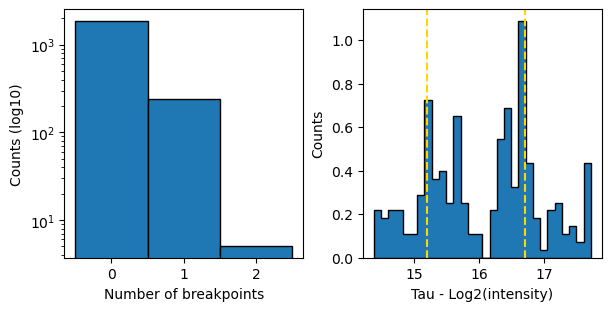

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,3), constrained_layout=True)

ax[0].hist([i['n_breakpoint'] for i in all_prot_bk], edgecolor='k', bins=[-0.5, 0.5, 1.5, 2.5])
ax[0].set_yscale('log')
ax[0].set_ylabel('Counts (log10)')
ax[0].set_xlabel('Number of breakpoints')
ax[0].set_xticks([0,1,2])

bk_point_values = [i['model'].get_params()['breakpoint1'] for i in all_prot_bk if i['n_breakpoint'] > 0]

ax[1].hist(bk_point_values, bins=30, histtype='stepfilled', edgecolor='k', density=True)
# sns.kdeplot(bk_point_values, ax=ax[1], lw=3, bw_adjust=1)
ax[1].set_ylabel('Counts')
ax[1].set_xlabel('Tau - Log2(intensity)')
ax[1].axvline(x=16.7, linestyle='dashed', color='gold')
ax[1].axvline(x=15.2, linestyle='dashed', color='gold')

fig.savefig(os.path.join(figure_path, 'Fig4cd_n_breakpoints.png'), dpi=300)

plt.show()

In [7]:
selected_bk = [i['GeneName'] for i in all_prot_bk if i['n_breakpoint'] == 1 and i['model'].get_params()['breakpoint1'] > 15 and i['model'].get_params()['breakpoint1'] < 17]

In [8]:
genename_idx = [i['GeneName'] for i in all_prot_bk]

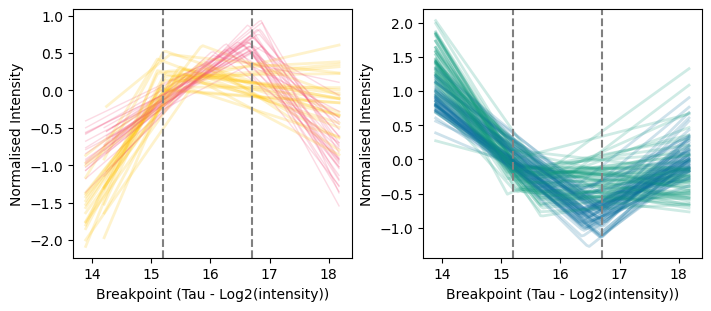

In [10]:
early_up_flat = []
late_up_down = []

plt.figure(figsize=(7,3), constrained_layout=True)

plt.subplot(1,2,1)
for i in selected_bk:
    if all_prot_bk[genename_idx.index(i)]['model'].get_params()['alpha1'] > 0:
        if all_prot_bk[genename_idx.index(i)]['model'].get_params()['breakpoint1'] < 16:
            all_prot_bk[genename_idx.index(i)]['model'].plot_fit(color="#FEC200", linewidth=2, alpha=0.2)
            early_up_flat.append(i)
        else:
            all_prot_bk[genename_idx.index(i)]['model'].plot_fit(color="#F24A7A", linewidth=1, alpha=0.2)
            late_up_down.append(i)


plt.axvline(x=16.7, linestyle='dashed', color='gray')
plt.axvline(x=15.2, linestyle='dashed', color='gray')
plt.xlabel("Breakpoint (Tau - Log2(intensity))")
plt.ylabel("Normalised Intensity")

plt.subplot(1,2,2)

early_down_flat = []
late_down_up = []

for i in selected_bk:
    if all_prot_bk[genename_idx.index(i)]['model'].get_params()['alpha1'] < 0:
        if all_prot_bk[genename_idx.index(i)]['model'].get_params()['breakpoint1'] < 16:
            all_prot_bk[genename_idx.index(i)]['model'].plot_fit(color="#139C7E", linewidth=2, alpha=0.2)
            early_down_flat.append(i)
        else:
            all_prot_bk[genename_idx.index(i)]['model'].plot_fit(color="#0C6F9F", linewidth=2, alpha=0.2)
            late_down_up.append(i)

plt.axvline(x=16.7, linestyle='dashed', color='gray')
plt.axvline(x=15.2, linestyle='dashed', color='gray')
plt.xlabel("Breakpoint (Tau - Log2(intensity))")
plt.ylabel("Normalised Intensity")

plt.savefig(os.path.join(figure_path, 'Fig4e_trajectories.png'), dpi=300)

plt.show()

In [12]:
with open(os.path.join(results_path, 'late_down_up.txt'), 'w') as f:
    f.write('\n'.join(late_down_up))
with open(os.path.join(results_path, 'early_up_flat.txt'), 'w') as f:
    f.write('\n'.join(early_up_flat))
with open(os.path.join(results_path, 'late_up_down.txt'), 'w') as f:
    f.write('\n'.join(late_up_down))
with open(os.path.join(results_path, 'early_down_flat.txt'), 'w') as f:
    f.write('\n'.join(early_down_flat))